In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

print('Libraries imported successfully.')

Libraries imported successfully.


In [4]:
MAIN_PATH = r'C:\Users\Payal\OneDrive\Documents\linkedin-fair-recommendation\data\synthetic_linkedin_dataset_30000.csv'

INTERACTIONS_PATH = r'C:\Users\Payal\OneDrive\Documents\linkedin-fair-recommendation\data\synthetic_linkedin_interactions_30000.csv'

POSTS_PATH = r'C:\Users\Payal\OneDrive\Documents\linkedin-fair-recommendation\data\synthetic_linkedin_posts_5000.csv'

interaction_df = pd.read_csv(MAIN_PATH)

interactions_df = pd.read_csv(INTERACTIONS_PATH)

posts_df = pd.read_csv(POSTS_PATH)

print('Datasets loaded successfully.')

print(f'Main interaction dataset: {interaction_df.shape}')
print(f'Second interaction dataset: {interactions_df.shape}')
print(f'Posts dataset: {posts_df.shape}')

Datasets loaded successfully.
Main interaction dataset: (30000, 22)
Second interaction dataset: (30000, 22)
Posts dataset: (5000, 7)


In [ ]:
print("Posts shape:")
print(posts_df.shape)

print("\nPosts columns:")
print(posts_df.columns.tolist())

print("\nFirst 10 posts:")
display(posts_df.head(10))

print("\nPost data types:")
posts_df.info()

## 2. Compare the two interaction datasets

In [6]:
if interaction_df.equals(interactions_df):
    print('RESULT: The two interaction CSV files contain exactly the same data.')
    print('For the project, synthetic_linkedin_dataset_30000.csv can be used as the single main interaction dataset.')
else:
    print('RESULT: The two interaction CSV files are not exactly identical.')
    print('Keep both files for further investigation before removing either one.')

RESULT: The two interaction CSV files contain exactly the same data.
For the project, synthetic_linkedin_dataset_30000.csv can be used as the single main interaction dataset.


## 3. Basic structure of the main interaction dataset

In [7]:
print('Shape:', interaction_df.shape)
print('Number of rows:', len(interaction_df))
print('Number of columns:', len(interaction_df.columns))

print('\nColumn names:')
for i, column in enumerate(interaction_df.columns, start=1):
    print(f'{i:2d}. {column}')

Shape: (30000, 22)
Number of rows: 30000
Number of columns: 22

Column names:
 1. user_id
 2. post_id
 3. author_id
 4. age_group
 5. gender
 6. location
 7. professional_field
 8. experience_years
 9. education
10. network_size
11. previous_interactions
12. post_topic
13. content_type
14. engagement
15. author_user_similarity
16. topic_similarity
17. post_age_hours
18. author_experience
19. author_network_size
20. network_distance
21. interaction_probability
22. interaction


In [8]:
interaction_df.head()

,user_id,post_id,author_id,age_group,gender,location,professional_field,experience_years,education,network_size,previous_interactions,post_topic,content_type,engagement,author_user_similarity,topic_similarity,post_age_hours,author_experience,author_network_size,network_distance,interaction_probability,interaction
0,U0234,P01910,A1658,26-35,Male,Delhi,Business,6.3,Masters,552,16,AI,Job Opportunity,0.3545,0.6148,0.5335,6.9,2.4,1129,1,0.6218,0
1,U1921,P00309,A0839,26-35,Male,Hyderabad,Marketing,3.4,Masters,195,13,Data Science,Image,0.5807,0.3575,0.4937,9.4,5.8,691,4,0.4049,1
2,U0952,P00581,A0063,18-25,Female,Other,Other,2.6,PhD,293,20,Software,Text,0.5121,0.8873,0.6062,1.6,3.1,597,3,0.7443,1
3,U2761,P04217,A0258,36-45,Male,Hyderabad,Finance,6.1,Masters,482,16,Leadership,Video,0.5860,0.3284,0.7435,18.5,9.6,170,2,0.5740,0
4,U2701,P02027,A0739,36-45,Female,Delhi,Finance,8.6,Bachelors,124,10,Marketing,Image,0.1472,0.5656,0.7147,5.4,1.0,167,2,0.5505,1


In [9]:
interaction_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  30000 non-null  str    
 1   post_id                  30000 non-null  str    
 2   author_id                30000 non-null  str    
 3   age_group                30000 non-null  str    
 4   gender                   30000 non-null  str    
 5   location                 30000 non-null  str    
 6   professional_field       30000 non-null  str    
 7   experience_years         30000 non-null  float64
 8   education                30000 non-null  str    
 9   network_size             30000 non-null  int64  
 10  previous_interactions    30000 non-null  int64  
 11  post_topic               30000 non-null  str    
 12  content_type             30000 non-null  str    
 13  engagement               30000 non-null  float64
 14  author_user_similarity   30000 no

## 4. Data quality checks

In [10]:
missing_values = interaction_df.isnull().sum().sort_values(ascending=False)

print('Missing values by column:')
display(missing_values.to_frame('missing_count'))

print('Total missing values:', int(interaction_df.isnull().sum().sum()))
print('Duplicate rows:', int(interaction_df.duplicated().sum()))

Missing values by column:


,missing_count
user_id,0
post_id,0
author_id,0
age_group,0
gender,0
location,0
professional_field,0
experience_years,0
education,0
network_size,0


Total missing values: 0
Duplicate rows: 0


In [11]:
print('Data types:')
display(interaction_df.dtypes.to_frame('dtype'))

Data types:


,dtype
user_id,str
post_id,str
author_id,str
age_group,str
gender,str
location,str
professional_field,str
experience_years,float64
education,str
network_size,int64


## 5. Target variable — `interaction`

In [12]:
target_counts = interaction_df['interaction'].value_counts().sort_index()
target_percent = interaction_df['interaction'].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'count': target_counts,
    'percentage': target_percent.round(2)
})

display(target_summary)

print('Target classes:', interaction_df['interaction'].unique())
print('Target mean:', round(interaction_df['interaction'].mean(), 4))

,count,percentage
interaction,,
0,14393,47.98
1,15607,52.02


Target classes: [0 1]
Target mean: 0.5202


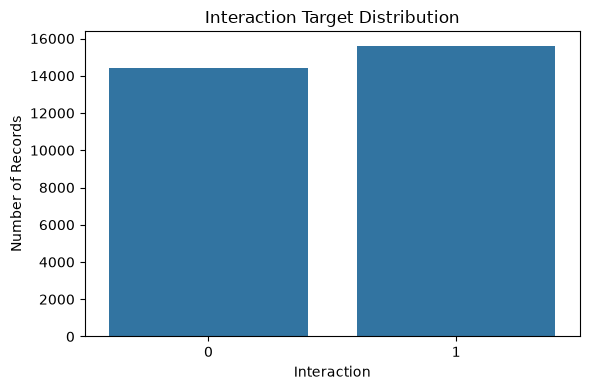

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=interaction_df, x='interaction')
plt.title('Interaction Target Distribution')
plt.xlabel('Interaction')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

## 6. Protected and audit attributes

The proposal focuses on group-level and intersectional fairness. Therefore, protected/audit attributes must remain available even when they are not used as baseline model features.

In [14]:
protected_attributes = ['gender', 'age_group', 'location']

for column in protected_attributes:
    print(f'\n===== {column} =====')
    counts = interaction_df[column].value_counts()
    percentages = interaction_df[column].value_counts(normalize=True) * 100
    summary = pd.DataFrame({
        'count': counts,
        'percentage': percentages.round(2)
    })
    display(summary)


===== gender =====


,count,percentage
gender,,
Male,16733,55.78
Female,13267,44.22



===== age_group =====


,count,percentage
age_group,,
26-35,10230,34.10
18-25,8402,28.01
36-45,5720,19.07
46-55,3769,12.56
56+,1879,6.26



===== location =====


,count,percentage
location,,
Mumbai,5319,17.73
Bengaluru,4972,16.57
Delhi,3771,12.57
Other,3665,12.22
Hyderabad,3159,10.53
Pune,2869,9.56
Chennai,2557,8.52
Kolkata,1946,6.49
Ahmedabad,1742,5.81


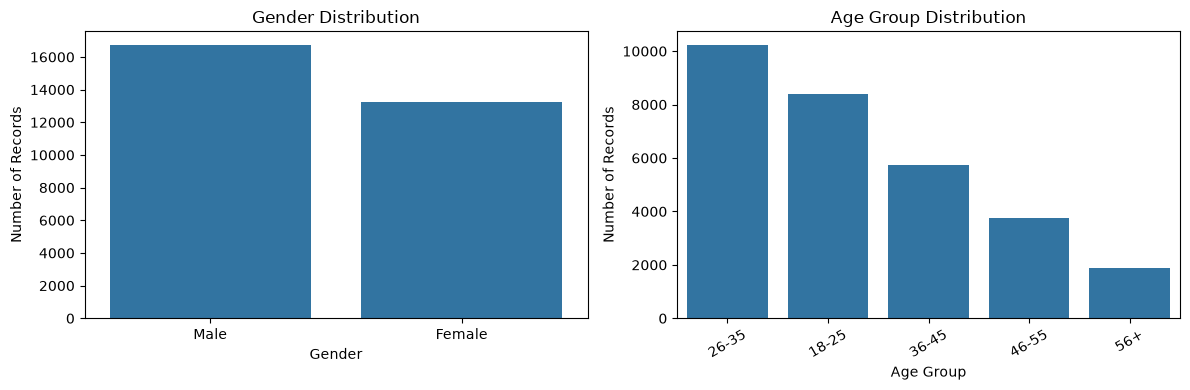

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=interaction_df, x='gender', ax=axes[0])
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Records')

sns.countplot(data=interaction_df, x='age_group', ax=axes[1])
axes[1].set_title('Age Group Distribution')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Records')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7. Interaction rate by protected groups

In [16]:
for column in ['gender', 'age_group', 'location']:
    print(f'\nInteraction rate by {column}:')
    rate = interaction_df.groupby(column)['interaction'].agg(['count', 'mean'])
    rate = rate.rename(columns={'mean': 'interaction_rate'})
    rate['interaction_rate'] = (rate['interaction_rate'] * 100).round(2)
    display(rate.sort_values('interaction_rate', ascending=False))


Interaction rate by gender:


,count,interaction_rate
gender,,
Female,13267,52.20
Male,16733,51.88



Interaction rate by age_group:


,count,interaction_rate
age_group,,
46-55,3769,53.41
18-25,8402,52.04
26-35,10230,52.04
36-45,5720,51.64
56+,1879,50.24



Interaction rate by location:


,count,interaction_rate
location,,
Mumbai,5319,53.47
Delhi,3771,53.30
Hyderabad,3159,52.58
Bengaluru,4972,52.47
Kolkata,1946,51.95
Ahmedabad,1742,51.26
Pune,2869,50.71
Chennai,2557,50.61
Other,3665,49.93


## 8. Categorical feature inspection

In [17]:
categorical_columns = interaction_df.select_dtypes(include=['object', 'string']).columns.tolist()

print('Categorical columns:')
print(categorical_columns)

for column in categorical_columns:
    print(f'\n{column}: {interaction_df[column].nunique()} unique values')
    print(interaction_df[column].value_counts().head(15))

Categorical columns:
['user_id', 'post_id', 'author_id', 'age_group', 'gender', 'location', 'professional_field', 'education', 'post_topic', 'content_type']

user_id: 3000 unique values
user_id
U0620    24
U1281    23
U2433    22
U2320    21
U1630    21
U0296    21
U1823    21
U1774    21
U2918    21
U2243    21
U1069    20
U2352    20
U1467    20
U2156    20
U1924    20
Name: count, dtype: int64

post_id: 4986 unique values
post_id
P01269    16
P00531    16
P03818    15
P02045    15
P04317    15
P01806    15
P04972    14
P02995    14
P02839    14
P01091    14
P04461    14
P02395    14
P02986    13
P01474    13
P04099    13
Name: count, dtype: int64

author_id: 2000 unique values
author_id
A0290    29
A1347    28
A0907    28
A1816    28
A1752    27
A1773    27
A0159    27
A0150    26
A0717    26
A1094    26
A0655    26
A1524    26
A0558    26
A0663    25
A1455    25
Name: count, dtype: int64

age_group: 5 unique values
age_group
26-35    10230
18-25     8402
36-45     5720
46-55     37

## 9. Numerical feature inspection

In [18]:
numerical_columns = interaction_df.select_dtypes(include=[np.number]).columns.tolist()
print('Numerical columns:')
print(numerical_columns)

display(interaction_df[numerical_columns].describe().T)

Numerical columns:
['experience_years', 'network_size', 'previous_interactions', 'engagement', 'author_user_similarity', 'topic_similarity', 'post_age_hours', 'author_experience', 'author_network_size', 'network_distance', 'interaction_probability', 'interaction']


,count,mean,std,min,25%,50%,75%,max
experience_years,30000.0,5.566990,3.683248,0.3000,2.900000,4.70000,7.300000,24.7000
network_size,30000.0,323.834633,262.789221,22.0000,152.000000,248.00000,407.000000,2339.0000
previous_interactions,30000.0,17.972533,4.256209,5.0000,15.000000,18.00000,21.000000,35.0000
engagement,30000.0,0.354684,0.177146,0.0051,0.216100,0.34085,0.475600,0.9555
author_user_similarity,30000.0,0.545945,0.195308,0.0179,0.401700,0.55155,0.694000,0.9975
topic_similarity,30000.0,0.601054,0.200422,0.0084,0.455775,0.61640,0.758700,0.9985
post_age_hours,30000.0,30.128297,29.927883,0.0000,8.900000,20.80000,42.100000,245.7000
author_experience,30000.0,5.992373,3.855381,0.0000,3.200000,5.10000,8.000000,25.0000
author_network_size,30000.0,454.368533,430.807973,20.0000,194.000000,331.00000,565.250000,5469.0000
network_distance,30000.0,2.667400,1.187051,1.0000,2.000000,3.00000,4.000000,5.0000


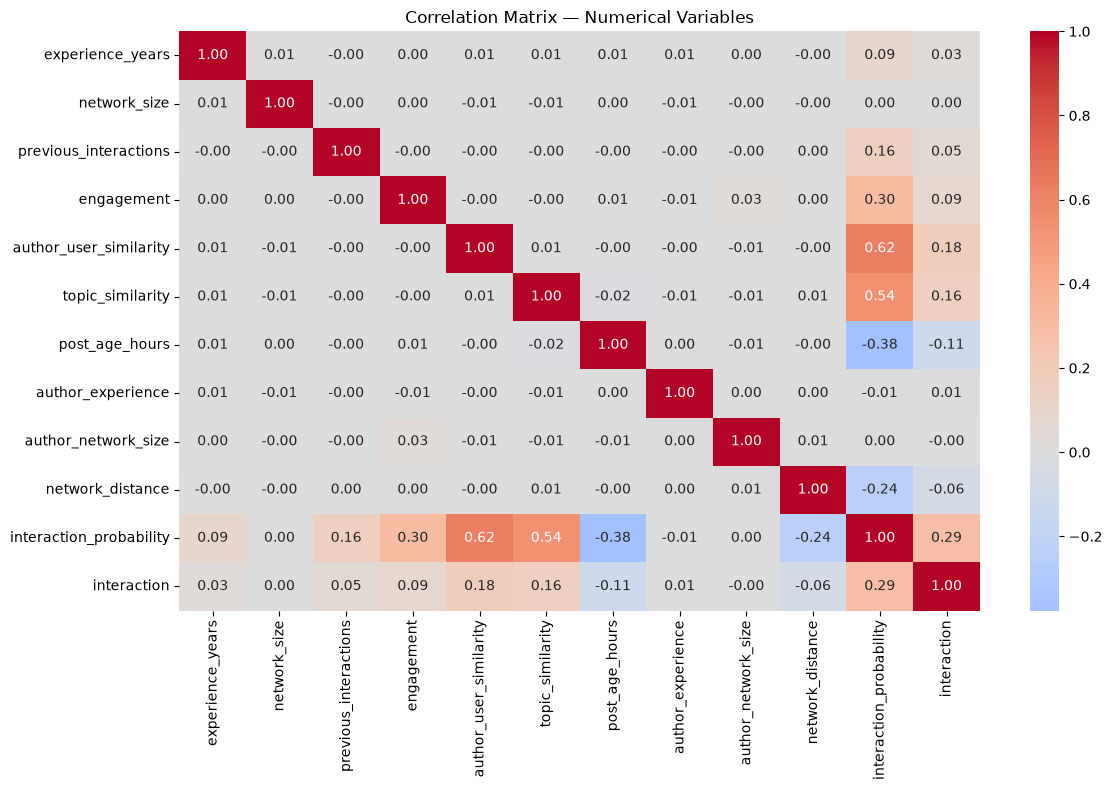

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    interaction_df[numerical_columns].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Matrix — Numerical Variables')
plt.tight_layout()
plt.show()

## 10. Investigate `interaction_probability`

`interaction_probability` needs special attention. If this value was used to generate the target `interaction`, using it as a model feature would create target leakage.

We therefore inspect its relationship with the target before preprocessing.

In [20]:
display(
    interaction_df[['interaction_probability', 'interaction']].head(20)
)

print('Interaction probability statistics by target:')
display(
    interaction_df.groupby('interaction')['interaction_probability'].describe()
)

,interaction_probability,interaction
0,0.6218,0
1,0.4049,1
2,0.7443,1
3,0.5740,0
4,0.5505,1
5,0.7321,1
6,0.5972,0
7,0.6270,1
8,0.2964,0
9,0.5042,1


Interaction probability statistics by target:


,count,mean,std,min,25%,50%,75%,max
interaction,,,,,,,,
0,14393.0,0.474937,0.143733,0.0732,0.3713,0.4744,0.5795,0.8695
1,15607.0,0.560616,0.135996,0.1085,0.4670,0.5688,0.6636,0.8881


In [21]:
probability_target_corr = interaction_df[['interaction_probability', 'interaction']].corr().iloc[0, 1]
print('Correlation between interaction_probability and interaction:', round(probability_target_corr, 4))

Correlation between interaction_probability and interaction: 0.2929


In [22]:
probability_bins = pd.cut(
    interaction_df['interaction_probability'],
    bins=10,
    include_lowest=True
)

probability_target_rate = interaction_df.groupby(
    probability_bins,
    observed=False
)['interaction'].agg(['count', 'mean'])

probability_target_rate = probability_target_rate.rename(
    columns={'mean': 'interaction_rate'}
)
probability_target_rate['interaction_rate'] = (
    probability_target_rate['interaction_rate'] * 100
).round(2)

display(probability_target_rate)

,count,interaction_rate
interaction_probability,,
"(0.0714, 0.155]",126,7.94
"(0.155, 0.236]",709,20.03
"(0.236, 0.318]",2007,27.15
"(0.318, 0.399]",3711,37.00
"(0.399, 0.481]",5185,43.78
"(0.481, 0.562]",6022,52.89
"(0.562, 0.644]",5698,59.79
"(0.644, 0.725]",4210,68.65
"(0.725, 0.807]",1985,76.22


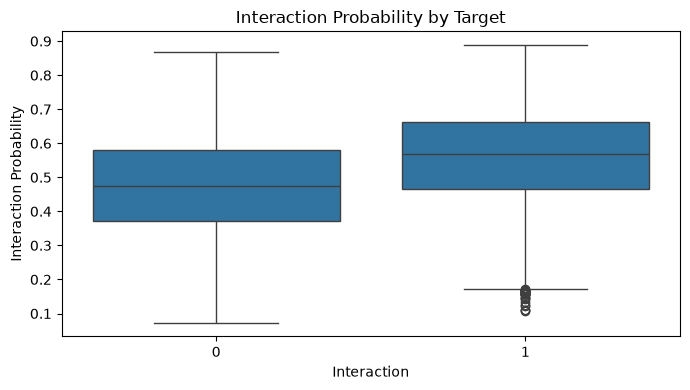

In [23]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=interaction_df, x='interaction', y='interaction_probability')
plt.title('Interaction Probability by Target')
plt.xlabel('Interaction')
plt.ylabel('Interaction Probability')
plt.tight_layout()
plt.show()

### Leakage decision

The analysis above should be interpreted together with how the synthetic dataset was generated.

For a conservative recommendation-model baseline, `interaction_probability` will be **excluded from the XGBoost input features** unless we can establish that it is an independent feature available before the interaction occurs.

The column can still be retained in the raw dataset for analysis.

## 11. Define the initial feature groups

In [24]:
id_columns = [
    'user_id',
    'post_id',
    'author_id'
]

protected_columns = [
    'gender',
    'age_group',
    'location'
]

categorical_recommendation_features = [
    'professional_field',
    'education',
    'post_topic',
    'content_type'
]

numerical_recommendation_features = [
    'experience_years',
    'network_size',
    'previous_interactions',
    'engagement',
    'author_user_similarity',
    'topic_similarity',
    'post_age_hours',
    'author_experience',
    'author_network_size',
    'network_distance'
]

target_column = 'interaction'
potential_leakage_column = 'interaction_probability'

print('ID columns:')
print(id_columns)

print('\nProtected/audit columns:')
print(protected_columns)

print('\nCategorical recommendation features:')
print(categorical_recommendation_features)

print('\nNumerical recommendation features:')
print(numerical_recommendation_features)

print('\nTarget:')
print(target_column)

print('\nPotential leakage column:')
print(potential_leakage_column)

ID columns:
['user_id', 'post_id', 'author_id']

Protected/audit columns:
['gender', 'age_group', 'location']

Categorical recommendation features:
['professional_field', 'education', 'post_topic', 'content_type']

Numerical recommendation features:
['experience_years', 'network_size', 'previous_interactions', 'engagement', 'author_user_similarity', 'topic_similarity', 'post_age_hours', 'author_experience', 'author_network_size', 'network_distance']

Target:
interaction

Potential leakage column:
interaction_probability


## 12. Check that the proposed feature groups exist

This prevents spelling mistakes or missing columns from silently reaching the preprocessing stage.

In [25]:
all_required_columns = (
    id_columns
    + protected_columns
    + categorical_recommendation_features
    + numerical_recommendation_features
    + [target_column, potential_leakage_column]
)

missing_required = [
    column for column in all_required_columns
    if column not in interaction_df.columns
]

if missing_required:
    print('Missing expected columns:', missing_required)
else:
    print('All expected columns are present.')

All expected columns are present.


## 13. Inspect the 5,000-post dataset

In [26]:
print('Posts dataset shape:', posts_df.shape)
print('\nPost dataset columns:')
print(posts_df.columns.tolist())

print('\nFirst five posts:')
display(posts_df.head())

print('\nMissing values:')
display(posts_df.isnull().sum().to_frame('missing_count'))

print('\nDuplicate rows:', posts_df.duplicated().sum())

Posts dataset shape: (5000, 7)

Post dataset columns:
['post_id', 'post_topic', 'content_type', 'engagement', 'post_age_hours', 'author_experience', 'author_network_size']

First five posts:


,post_id,post_topic,content_type,engagement,post_age_hours,author_experience,author_network_size
0,P00001,Career,Article,0.1221,6.8,8.3,272
1,P00002,Career,Video,0.4864,12.2,9.8,333
2,P00003,Data Science,Article,0.2736,9.7,6.3,515
3,P00004,Data Science,Text,0.3670,33.5,3.8,336
4,P00005,Finance,Text,0.3171,7.4,14.8,168



Missing values:


,missing_count
post_id,0
post_topic,0
content_type,0
engagement,0
post_age_hours,0
author_experience,0
author_network_size,0



Duplicate rows: 0


## 14. Verify user-post relationships

The interaction dataset should reference users and posts. We check whether its `post_id` values exist in the 5,000-post dataset.

In [27]:
if 'post_id' in posts_df.columns:
    interaction_post_ids = set(interaction_df['post_id'].unique())
    post_ids = set(posts_df['post_id'].unique())

    missing_post_ids = interaction_post_ids - post_ids

    print('Unique post IDs in interaction dataset:', len(interaction_post_ids))
    print('Unique post IDs in posts dataset:', len(post_ids))
    print('Interaction post IDs missing from posts dataset:', len(missing_post_ids))

    if len(missing_post_ids) > 0:
        print('Example missing IDs:', list(missing_post_ids)[:10])
else:
    print('The posts dataset does not contain a post_id column, so the relationship cannot be checked using post_id.')

Unique post IDs in interaction dataset: 4986
Unique post IDs in posts dataset: 5000
Interaction post IDs missing from posts dataset: 0


## 15. Final dataset summary

This is the checkpoint before moving to preprocessing.

In [28]:
summary = {
    'interaction_rows': len(interaction_df),
    'interaction_columns': len(interaction_df.columns),
    'post_rows': len(posts_df),
    'missing_values': int(interaction_df.isnull().sum().sum()),
    'duplicate_rows': int(interaction_df.duplicated().sum()),
    'positive_interactions': int((interaction_df['interaction'] == 1).sum()),
    'negative_interactions': int((interaction_df['interaction'] == 0).sum()),
    'male_records': int((interaction_df['gender'] == 'Male').sum()),
    'female_records': int((interaction_df['gender'] == 'Female').sum()),
    'unique_users': interaction_df['user_id'].nunique(),
    'unique_posts_in_interactions': interaction_df['post_id'].nunique(),
    'unique_authors': interaction_df['author_id'].nunique()
}

display(pd.Series(summary).to_frame('value'))

,value
interaction_rows,30000
interaction_columns,22
post_rows,5000
missing_values,0
duplicate_rows,0
positive_interactions,15607
negative_interactions,14393
male_records,16733
female_records,13267
unique_users,3000


In [4]:
import pandas as pd
from pathlib import Path

# ============================================================
# 1. FIND PROJECT FOLDER
# ============================================================

BASE_DIR = Path.cwd().parent

print("Project folder:")
print(BASE_DIR)

print()


# ============================================================
# 2. POSTS DATASET PATH
# ============================================================

POSTS_PATH = (
    BASE_DIR
    / "data"
    / "synthetic_linkedin_posts_5000.csv"
)

print("Posts dataset path:")
print(POSTS_PATH)

print()


# ============================================================
# 3. CHECK WHETHER FILE EXISTS
# ============================================================

if not POSTS_PATH.exists():

    print("ERROR: Posts dataset was not found.")

    print()
    print("Files inside data folder:")

    data_folder = BASE_DIR / "data"

    if data_folder.exists():

        for file in data_folder.iterdir():
            print(file.name)

    else:

        print("Data folder was not found.")

else:

    print("Posts dataset found successfully.")

    print()


    # ========================================================
    # 4. LOAD POSTS DATASET
    # ========================================================

    posts_df = pd.read_csv(POSTS_PATH)

    print("=" * 60)
    print("POST DATASET INFORMATION")
    print("=" * 60)

    print()

    print("Shape:")
    print(posts_df.shape)

    print()

    print("Number of rows:")
    print(len(posts_df))

    print()

    print("Number of columns:")
    print(len(posts_df.columns))

    print()


    # ========================================================
    # 5. COLUMN NAMES
    # ========================================================

    print("=" * 60)
    print("POST DATASET COLUMNS")
    print("=" * 60)

    for i, column in enumerate(posts_df.columns, start=1):
        print(f"{i}. {column}")

    print()


    # ========================================================
    # 6. FIRST 10 RECORDS
    # ========================================================

    print("=" * 60)
    print("FIRST 10 POSTS")
    print("=" * 60)

    display(posts_df.head(10))

    print()


    # ========================================================
    # 7. DATA TYPES
    # ========================================================

    print("=" * 60)
    print("DATA TYPES")
    print("=" * 60)

    print(posts_df.dtypes)

    print()


    # ========================================================
    # 8. DATASET INFO
    # ========================================================

    print("=" * 60)
    print("DATASET INFO")
    print("=" * 60)

    posts_df.info()

    print()


    # ========================================================
    # 9. MISSING VALUES
    # ========================================================

    print("=" * 60)
    print("MISSING VALUES")
    print("=" * 60)

    missing_values = posts_df.isnull().sum()

    print(missing_values)

    print()

    print(
        "Total missing values:",
        posts_df.isnull().sum().sum()
    )

    print()


    # ========================================================
    # 10. DUPLICATES
    # ========================================================

    print("=" * 60)
    print("DUPLICATES")
    print("=" * 60)

    print(
        "Duplicate rows:",
        posts_df.duplicated().sum()
    )

    print()


    # ========================================================
    # 11. POST ID CHECK
    # ========================================================

    if "post_id" in posts_df.columns:

        print("=" * 60)
        print("POST ID CHECK")
        print("=" * 60)

        print(
            "Total post records:",
            len(posts_df)
        )

        print(
            "Unique post IDs:",
            posts_df["post_id"].nunique()
        )

        print()

        print("First 20 post IDs:")

        print(
            posts_df["post_id"].head(20).tolist()
        )

    else:

        print(
            "WARNING: 'post_id' column does not exist."
        )

Project folder:
c:\Users\Payal\OneDrive\Documents\linkedin-fair-recommendation

Posts dataset path:
c:\Users\Payal\OneDrive\Documents\linkedin-fair-recommendation\data\synthetic_linkedin_posts_5000.csv

Posts dataset found successfully.

POST DATASET INFORMATION

Shape:
(5000, 7)

Number of rows:
5000

Number of columns:
7

POST DATASET COLUMNS
1. post_id
2. post_topic
3. content_type
4. engagement
5. post_age_hours
6. author_experience
7. author_network_size

FIRST 10 POSTS


,post_id,post_topic,content_type,engagement,post_age_hours,author_experience,author_network_size
0,P00001,Career,Article,0.1221,6.8,8.3,272
1,P00002,Career,Video,0.4864,12.2,9.8,333
2,P00003,Data Science,Article,0.2736,9.7,6.3,515
3,P00004,Data Science,Text,0.3670,33.5,3.8,336
4,P00005,Finance,Text,0.3171,7.4,14.8,168
5,P00006,Machine Learning,Text,0.7258,3.6,4.0,244
6,P00007,Finance,Video,0.6584,157.5,1.4,381
7,P00008,Career,Article,0.4018,36.9,3.0,560
8,P00009,Leadership,Video,0.3930,31.3,12.1,735
9,P00010,AI,Video,0.3913,47.8,2.7,265



DATA TYPES
post_id                    str
post_topic                 str
content_type               str
engagement             float64
post_age_hours         float64
author_experience      float64
author_network_size      int64
dtype: object

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   post_id              5000 non-null   str    
 1   post_topic           5000 non-null   str    
 2   content_type         5000 non-null   str    
 3   engagement           5000 non-null   float64
 4   post_age_hours       5000 non-null   float64
 5   author_experience    5000 non-null   float64
 6   author_network_size  5000 non-null   int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 273.6 KB

MISSING VALUES
post_id                0
post_topic             0
content_type           0
engagement             0
post_age_hours        

In [6]:
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

interaction_df = pd.read_csv(
    DATA_DIR / "synthetic_linkedin_dataset_30000.csv"
)

posts_df = pd.read_csv(
    DATA_DIR / "synthetic_linkedin_posts_5000.csv"
)

# ------------------------------------------------------------
# Basic info
# ------------------------------------------------------------
print("=" * 60)
print("POST DATASET SUMMARY")
print("=" * 60)
print("Shape:", posts_df.shape)
print()

print("Columns:")
for i, col in enumerate(posts_df.columns, start=1):
    print(f"{i}. {col}")

# ------------------------------------------------------------
# First 5 posts (no truncation)
# ------------------------------------------------------------
for i in range(5):
    print("\n" + "=" * 60)
    print(f"POST {i + 1}")
    print("=" * 60)

    row = posts_df.iloc[i]
    for col in posts_df.columns:
        print(f"{col}: {row[col]}")

# ------------------------------------------------------------
# Relationship with interaction dataset
# ------------------------------------------------------------
interaction_ids = set(interaction_df["post_id"].unique())
post_ids = set(posts_df["post_id"].unique())

print("\n" + "=" * 60)
print("POST ID RELATIONSHIP")
print("=" * 60)
print("Unique post IDs in interactions :", len(interaction_ids))
print("Unique post IDs in posts        :", len(post_ids))
print("Common post IDs                 :", len(interaction_ids & post_ids))
print(
    "Interaction IDs missing in posts:",
    len(interaction_ids - post_ids)
)
print(
    "Posts never seen in interactions:",
    len(post_ids - interaction_ids)
)

POST DATASET SUMMARY
Shape: (5000, 7)

Columns:
1. post_id
2. post_topic
3. content_type
4. engagement
5. post_age_hours
6. author_experience
7. author_network_size

POST 1
post_id: P00001
post_topic: Career
content_type: Article
engagement: 0.1221
post_age_hours: 6.8
author_experience: 8.3
author_network_size: 272

POST 2
post_id: P00002
post_topic: Career
content_type: Video
engagement: 0.4864
post_age_hours: 12.2
author_experience: 9.8
author_network_size: 333

POST 3
post_id: P00003
post_topic: Data Science
content_type: Article
engagement: 0.2736
post_age_hours: 9.7
author_experience: 6.3
author_network_size: 515

POST 4
post_id: P00004
post_topic: Data Science
content_type: Text
engagement: 0.367
post_age_hours: 33.5
author_experience: 3.8
author_network_size: 336

POST 5
post_id: P00005
post_topic: Finance
content_type: Text
engagement: 0.3171
post_age_hours: 7.4
author_experience: 14.8
author_network_size: 168

POST ID RELATIONSHIP
Unique post IDs in interactions : 4986
Unique 

In [5]:
print("Current notebook directory:")
print(Path.cwd())

print()

print("Project data folder:")
print(BASE_DIR / "data")

print()

print("Files in data folder:")

for file in (BASE_DIR / "data").iterdir():
    print(file.name)

Current notebook directory:
c:\Users\Payal\OneDrive\Documents\linkedin-fair-recommendation\notebooks

Project data folder:
c:\Users\Payal\OneDrive\Documents\linkedin-fair-recommendation\data

Files in data folder:
synthetic_linkedin_dataset_30000.csv
synthetic_linkedin_interactions_30000.csv
synthetic_linkedin_posts_5000.csv
